# Surface Code
The d=3 surface code uses 9 data qubits and 8 ancilla qubits. Z-stabilizers detect X errors; X-stabilizers detect Z errors. PyMatching decodes syndromes using minimum weight perfect matching.

In [1]:
from qec.surface import build_surface_code, build_matching_graph, decode_surface, run_surface
from qec.visualize import plot_circuit, plot_threshold
from qec.benchmark import sweep_error_rates

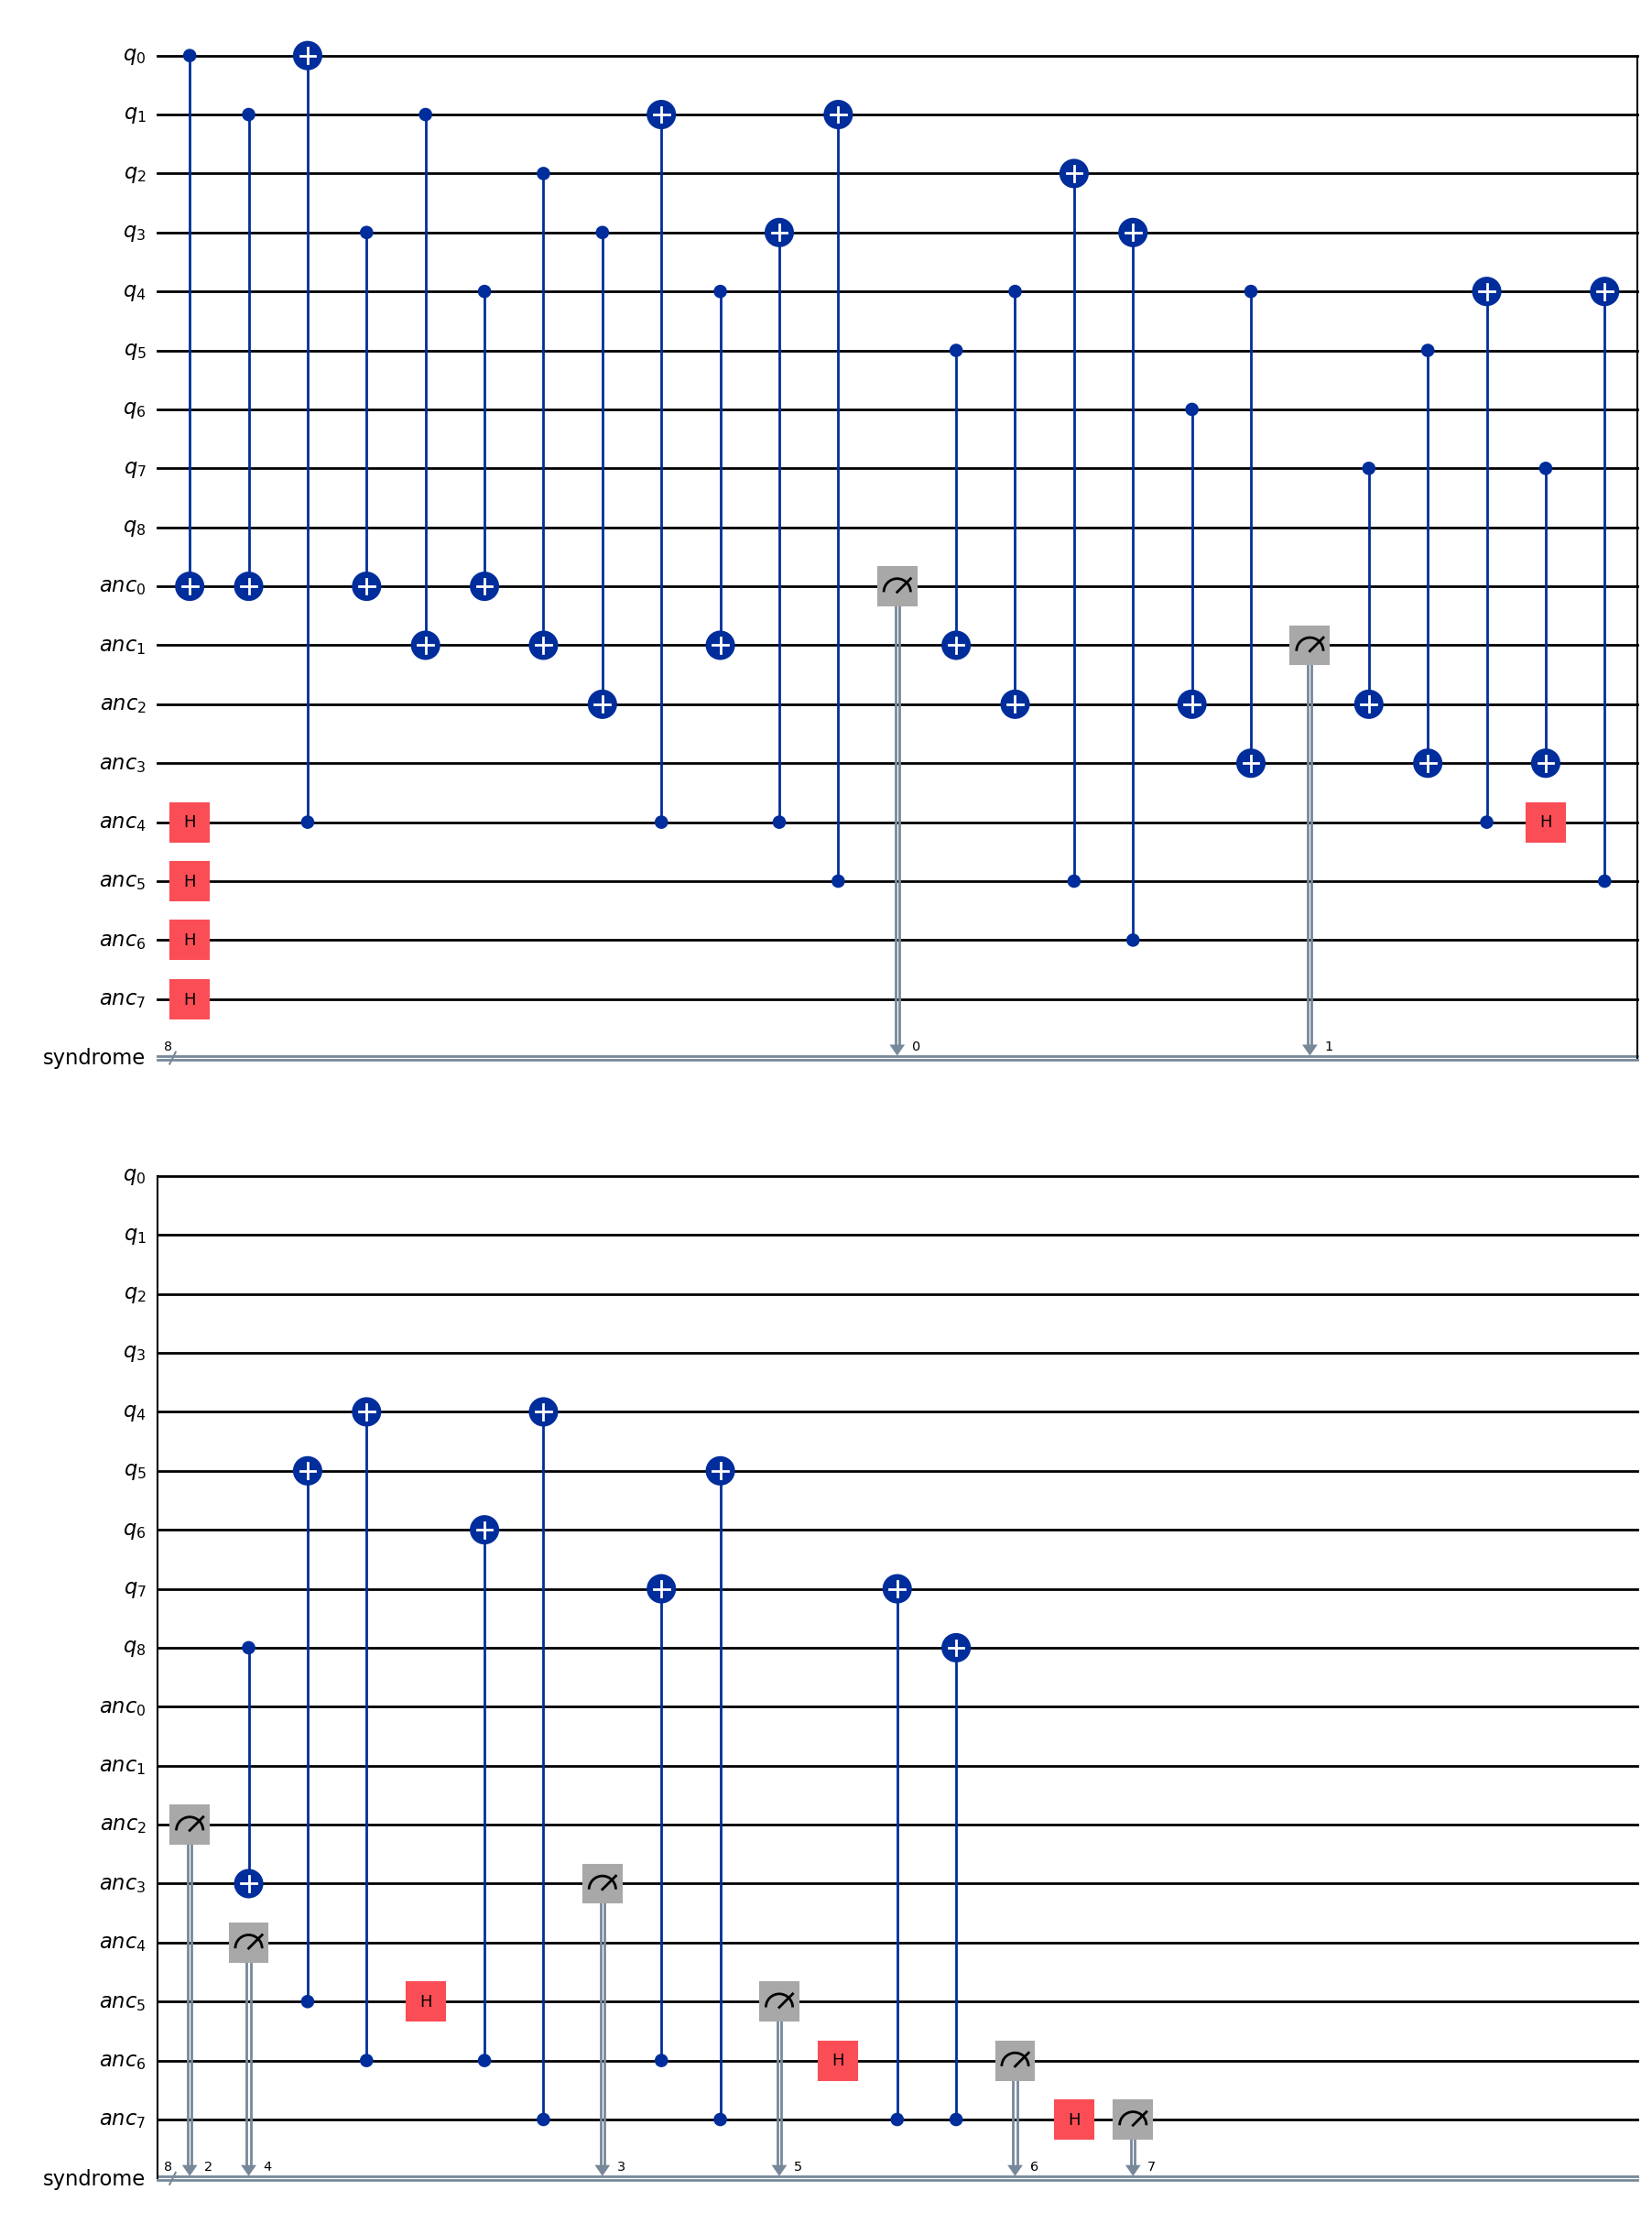

In [2]:
qc = build_surface_code(3)
fig = plot_circuit(qc, "surface_code_d3")
display(fig)

In [3]:
from qiskit_aer import AerSimulator
from qiskit import transpile
import numpy as np
simulator = AerSimulator()
tqc = transpile(qc, simulator)
result = simulator.run(tqc, shots=1).result()
bitstring = list(result.get_counts().keys())[0]
syndrome = [int(b) for b in bitstring]
matching = build_matching_graph()
corrections = decode_surface(syndrome, matching)
print("Syndrome:", syndrome)
print("Corrections:", corrections)

Syndrome: [1, 0, 0, 0, 0, 0, 0, 0]
Corrections: 1


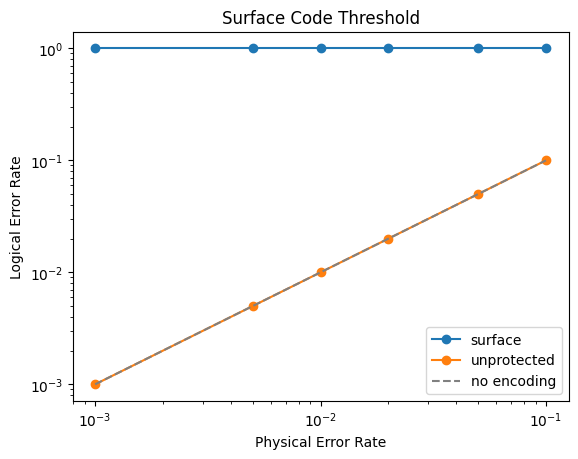

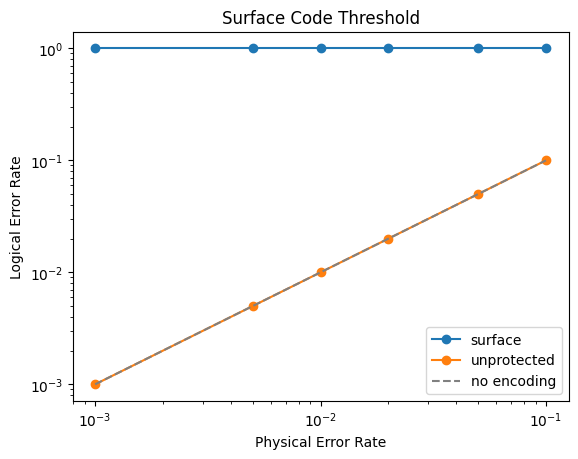

In [4]:
import pandas as pd
error_rates = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1]
df = sweep_error_rates("surface", error_rates, "depolarizing", shots=512)
df["code"] = "surface"
baseline = pd.DataFrame({"p_physical": error_rates, "p_logical": error_rates, "code": "unprotected"})
combined = pd.concat([df, baseline])
fig = plot_threshold(combined, "Surface Code Threshold")
display(fig)